---
# ENTREGA 3 — REDUCCIÓN DIMENSIONAL, CLUSTERING Y DEEP LEARNING

En esta entrega final se integran tres bloques de técnicas nuevas al problema de riesgo de reingreso hospitalario:

1. **Aprendizaje Supervisado completado** — Red neuronal MLP con tuning y análisis explícito de overfitting
2. **Reducción de Dimensionalidad** — PCA + t-SNE aplicados al espacio clínico
3. **Aprendizaje No Supervisado** — K-Means + DBSCAN para identificar perfiles de pacientes

Todos los resultados se comparan en una tabla final con los modelos del Corte 2.


## 1. Planteamiento del Problema — Corte 3

## Predicción de Reingreso Hospitalario a 30 Días

#### Planteamiento del Problema

El reingreso hospitalario dentro de los primeros 30 días posteriores al alta médica representa uno de los principales indicadores de calidad asistencial en los sistemas de salud. Un paciente readmitido en un corto periodo de tiempo puede reflejar complicaciones clínicas, seguimiento insuficiente, tratamientos inadecuados o presencia de múltiples comorbilidades.

Desde el punto de vista hospitalario, los reingresos generan:

- Sobrecarga operativa del sistema de salud.
- Incremento de costos hospitalarios.
- Mayor ocupación de camas.
- Riesgo elevado para pacientes vulnerables.
- Indicadores negativos de calidad clínica.

---

#### Motivación del Proyecto

La motivación principal de este proyecto es utilizar técnicas de aprendizaje supervisado y no supervisado para identificar patrones clínicos asociados al reingreso hospitalario temprano.

El objetivo no es únicamente obtener un modelo con alta precisión, sino construir un sistema clínicamente útil capaz de:

- Detectar pacientes de alto riesgo.
- Reducir falsos negativos (pacientes críticos no detectados).
- Apoyar decisiones médicas preventivas.
- Comprender patrones ocultos en los datos clínicos.

---

### Desafíos Técnicos del Problema

#### 1. Desbalance de Clases
El dataset presenta una distribución desigual (74% reingreso / 26% no reingreso), lo cual obliga a utilizar métricas robustas (Recall, F1, AUROC), validación estratificada y `class_weight=balanced`.

#### 2. Relaciones No Lineales
Variables clínicas como severidad, creatinina, edad y comorbilidades no presentan correlaciones lineales fuertes con el target, por lo que modelos simples no capturan correctamente las interacciones.

#### 3. Importancia Clínica de los Falsos Negativos
Un falso negativo implica que un paciente con alto riesgo no fue detectado. Esto es más crítico que generar falsas alarmas, por lo que el **Recall** adquiere especial relevancia.

---

## Objetivos Específicos — Corte 3

1. Implementar y optimizar una red neuronal densa (MLP).
2. Analizar explícitamente overfitting vs underfitting entre modelos.
3. Aplicar PCA y t-SNE para reducir dimensionalidad y visualizar separabilidad.
4. Identificar perfiles clínicos de pacientes mediante K-Means y DBSCAN.
5. Interpretar clínicamente los clusters y su relación con el riesgo de reingreso.
6. Comparar todos los modelos en una tabla final unificada.


## 2. EDA Complementario — Análisis Exploratorio Profundo

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Edad                          18000 non-null  int64   
 1   Genero                        18000 non-null  object  
 2   Tipo_Seguro                   18000 non-null  object  
 3   Riesgo_Socioeconomico         18000 non-null  int64   
 4   Hospitalizaciones_6M          18000 non-null  int64   
 5   Reingresos_1Año               18000 non-null  int64   
 6   Tiempo_Ultima_Alta            18000 non-null  int64   
 7   Duracion_Estancia             18000 non-null  int64   
 8   Tipo_Admision                 18000 non-null  object  
 9   Grupo_Diagnostico             18000 non-null  object  
 10  Indice_Comorbilidad           18000 non-null  int64   
 11  Numero_Enfermedades_Cronicas  18000 non-null  int64   
 12  Estuvo_UCI  

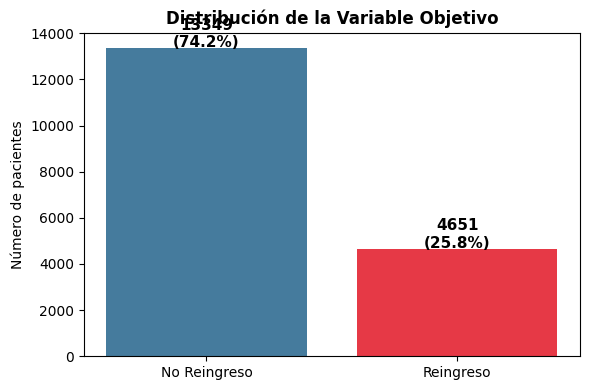


Correlaciones con el target:
Numero_Medicamentos             0.066307
Puntaje_Severidad               0.059043
Hospitalizaciones_6M            0.043686
Numero_Enfermedades_Cronicas    0.041126
Reingresos_1Año                 0.034802
Indice_Comorbilidad             0.030986
Cita_Control_Programada         0.028618
Estuvo_UCI                      0.026720
Medicacion_Alto_Riesgo          0.026430
Edad                            0.024315
Name: Reingreso_30_Dias, dtype: float64


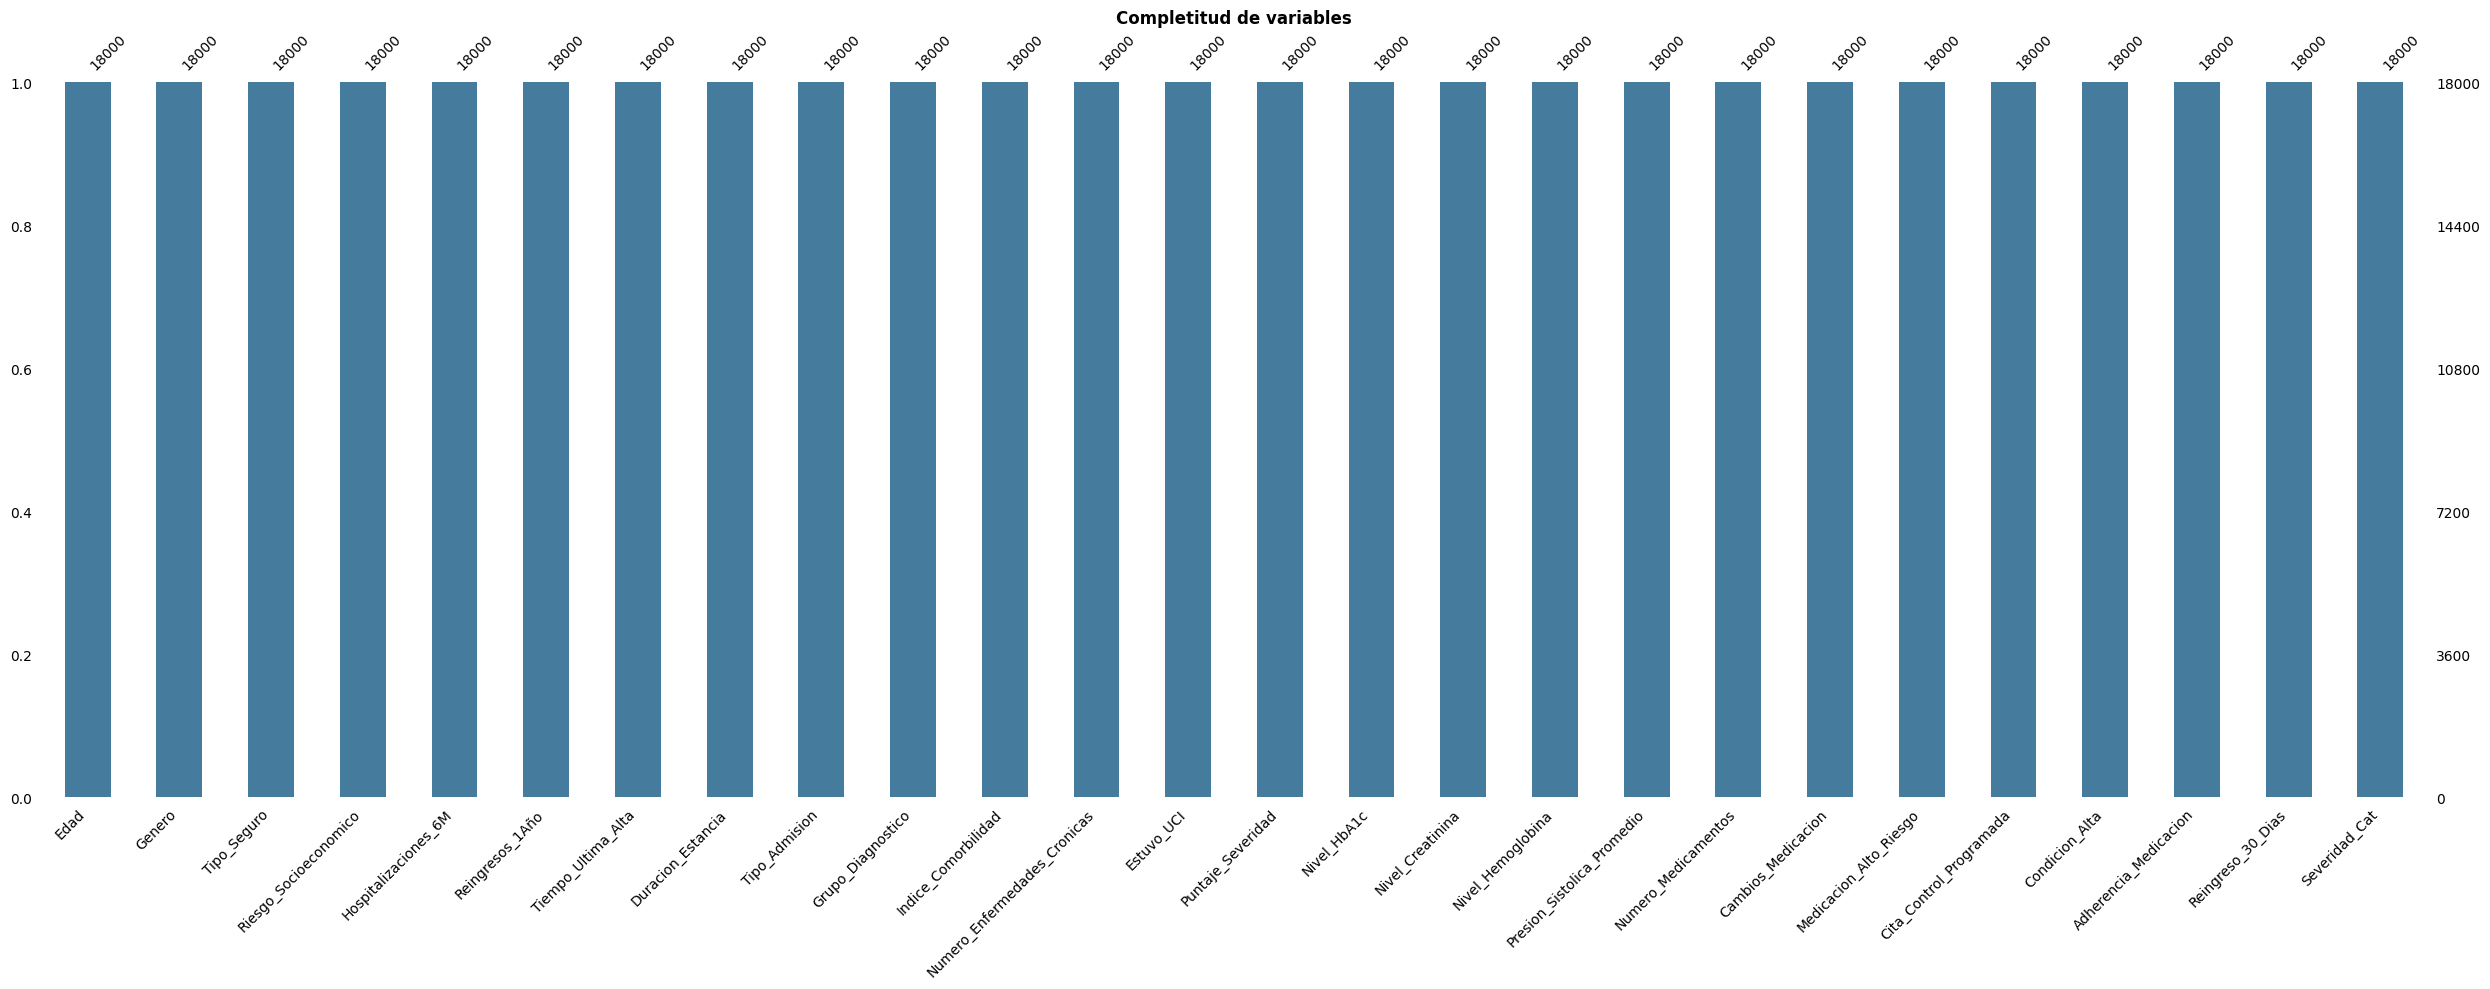

In [41]:
# ============================================================
# CELDA 13 — EDA COMPLEMENTARIO CORTE 3
# ============================================================

import missingno as msno

print("=" * 60)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(df.info())
print("\nShape:", df.shape)
print("\nValores faltantes:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

# Distribución del target
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = df['Reingreso_30_Dias'].value_counts()
bars = ax.bar(['No Reingreso', 'Reingreso'], target_counts.values,
              color=['#457B9D', '#E63946'])
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución de la Variable Objetivo', fontweight='bold')
ax.set_ylabel('Número de pacientes')
plt.tight_layout()
plt.show()

# Correlaciones con el target
print("\nCorrelaciones con el target:")
corr_target = df.corr(numeric_only=True)['Reingreso_30_Dias'].drop('Reingreso_30_Dias')
print(corr_target.abs().sort_values(ascending=False).head(10))

# Missingno
plt.figure(figsize=(12, 4))
msno.bar(df, color='#457B9D', fontsize=10)
plt.title('Completitud de variables', fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Workflow de Aprendizaje Supervisado — Corte 3

# Workflow de Aprendizaje Supervisado

El pipeline supervisado implementado en este proyecto sigue las siguientes etapas:

---

## 1. Preprocesamiento
- Limpieza de datos, corrección de valores inválidos, One-Hot Encoding, estandarización con StandardScaler.

## 2. División Train/Test
- 80% entrenamiento / 20% prueba con estratificación para preservar la proporción de clases.

## 3. Validación Cruzada
- Stratified K-Fold Cross Validation (k=5) para obtener métricas robustas.

## 4. Modelos Implementados

### Modelos clásicos
- Gaussian Naive Bayes, Decision Tree, Random Forest, SVM

### Red neuronal densa
- MLPClassifier (128 → 64 → sigmoide, activación ReLU, optimizador Adam)

## 5. Ajuste de Hiperparámetros
- GridSearchCV optimizando AUROC, Recall y F1 según importancia clínica.

## 6. Evaluación Final
- AUROC, Recall, Precision, F1, Matriz de confusión, Curvas ROC.

## 7. Análisis de Generalización
- Estudio explícito de Overfitting / Underfitting con diferencias train/test.


### CELDA 14 — Baseline MLP

In [42]:
# ============================================================
# CELDA 14 — BASELINE MLP
# ============================================================

from sklearn.neural_network import MLPClassifier

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)

print("Evaluando MLP Baseline...")

mlp_results = eval_cv(
    mlp_baseline,
    X_train,
    y_train,
    cv=5,
    label='MLP Baseline'
)


Evaluando MLP Baseline...

──────────────────────────────────────────────────
  CV Resultados: MLP Baseline
──────────────────────────────────────────────────
  accuracy     0.6273  +/-  0.0065
  precision    0.7464  +/-  0.0044
  recall       0.7533  +/-  0.0084
  f1           0.7499  +/-  0.0050
  roc_auc      0.5118  +/-  0.0127


### CELDA 15 — Tuning MLP (GridSearchCV)

In [43]:
# ============================================================
# CELDA 15 — TUNING MLP
# ============================================================

param_grid_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=700, random_state=42),
    param_grid=param_grid_mlp,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_mlp.fit(X_train, y_train)

print("\nMejores parámetros MLP:", grid_mlp.best_params_)
print("Mejor AUROC:", grid_mlp.best_score_)

best_mlp = grid_mlp.best_estimator_


Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros MLP: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01}
Mejor AUROC: 0.5315367709632999


### CELDA 16 — Análisis Explícito de Overfitting


=== ANÁLISIS DE OVERFITTING ===
              Train_Accuracy  Test_Accuracy  Gap (Overfitting)
Modelo                                                        
DecisionTree          0.7416         0.7417            -0.0001
RandomForest          0.6249         0.5689             0.0560
SVM                   0.5542         0.5333             0.0208
MLP                   0.7573         0.7206             0.0367


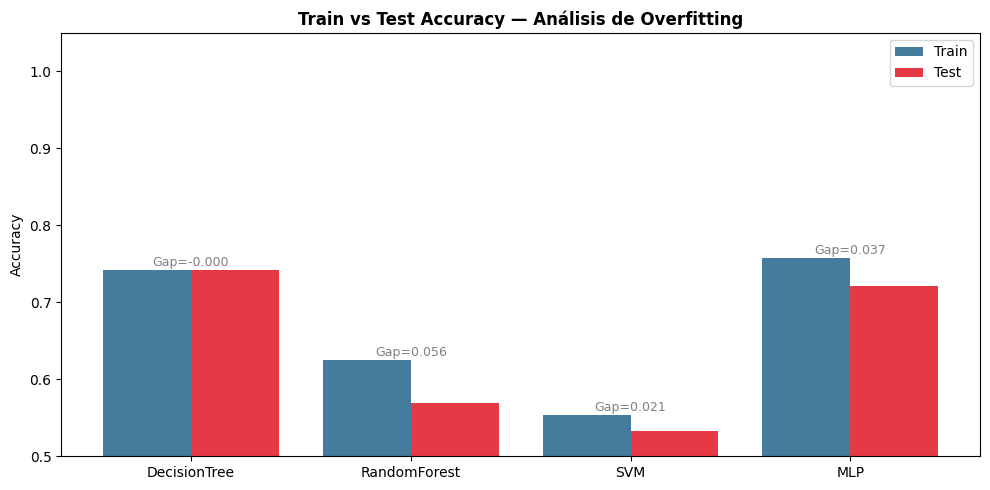


Interpretación:
- Gap alto = Overfitting (memoriza train, no generaliza)
- Gap bajo = Buen balance bias-varianza
- Gap negativo o ~0 = Underfitting o modelo robusto


In [45]:
from sklearn.metrics import accuracy_score

modelos_overfit = {
    'DecisionTree': best_dt,
    'RandomForest': best_rf,
    'SVM': best_svm,
    'MLP': best_mlp
}

rows_overfit = []

for nombre, modelo in modelos_overfit.items():
    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)
    train_acc  = accuracy_score(y_train, pred_train)
    test_acc   = accuracy_score(y_test, pred_test)
    gap        = train_acc - test_acc
    rows_overfit.append({
        'Modelo': nombre,
        'Train_Accuracy': round(train_acc, 4),
        'Test_Accuracy': round(test_acc, 4),
        'Gap (Overfitting)': round(gap, 4)
    })

df_overfit = pd.DataFrame(rows_overfit).set_index('Modelo')
print("\n=== ANÁLISIS DE OVERFITTING ===")
print(df_overfit.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_overfit))
ax.bar([i - 0.2 for i in x], df_overfit['Train_Accuracy'],
       width=0.4, label='Train', color='#457B9D')
ax.bar([i + 0.2 for i in x], df_overfit['Test_Accuracy'],
       width=0.4, label='Test', color='#E63946')
ax.set_xticks(list(x))
ax.set_xticklabels(df_overfit.index, rotation=0)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — Análisis de Overfitting', fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
for i, row in enumerate(df_overfit.itertuples()):
    ax.text(i, max(row.Train_Accuracy, row.Test_Accuracy) + 0.005,
            f'Gap={row[3]:.3f}', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Gap alto = Overfitting (memoriza train, no generaliza)")
print("- Gap bajo = Buen balance bias-varianza")
print("- Gap negativo o ~0 = Underfitting o modelo robusto")


## 4. Workflow de Aprendizaje No Supervisado y Reducción de Dimensionalidad

# Workflow de Aprendizaje No Supervisado y Reducción de Dimensionalidad

El objetivo del análisis no supervisado es identificar patrones ocultos y agrupaciones naturales de pacientes **sin utilizar la variable objetivo**.

---

## 1. Preprocesamiento
- One-Hot Encoding + escalado con StandardScaler (mismo que supervisado).

## 2. Reducción de Dimensionalidad

### PCA
- Reducir ruido, compactar información, visualizar estructura global, analizar varianza explicada.

### t-SNE
- Visualizar relaciones no lineales, detectar posibles clusters ocultos que PCA no captura.

## 3. Clustering

### K-Means
- Segmentar pacientes, encontrar grupos clínicos similares mediante el criterio del Silhouette.

### DBSCAN
- Detectar densidades variables, identificar outliers y clusters de forma arbitraria.

## 4. Evaluación
- Silhouette Score, visualizaciones 2D, perfilamiento de clusters, interpretación clínica.

---

> **Conexión con el curso:** PCA proviene del álgebra lineal (descomposición SVD); t-SNE minimiza divergencia KL en espacio reducido; K-Means es un algoritmo EM; DBSCAN usa grafos de densidad — todos vistos en los notebooks 14 y 15 del curso.


### CELDA 17 — Importaciones y preparación

In [46]:
# ============================================================
# CELDA 17 — IMPORTS NO SUPERVISADO
# ============================================================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

print("Librerías de reducción dimensional y clustering importadas correctamente.")
print(f"Datos disponibles: X_scaled shape = {X_scaled.shape}")


Librerías de reducción dimensional y clustering importadas correctamente.
Datos disponibles: X_scaled shape = (18000, 30)


### CELDA 18 — PCA: Varianza explicada y scatter 2D

Variables originales     : 30
Componentes para 90% var : 25
Componentes para 95% var : 27


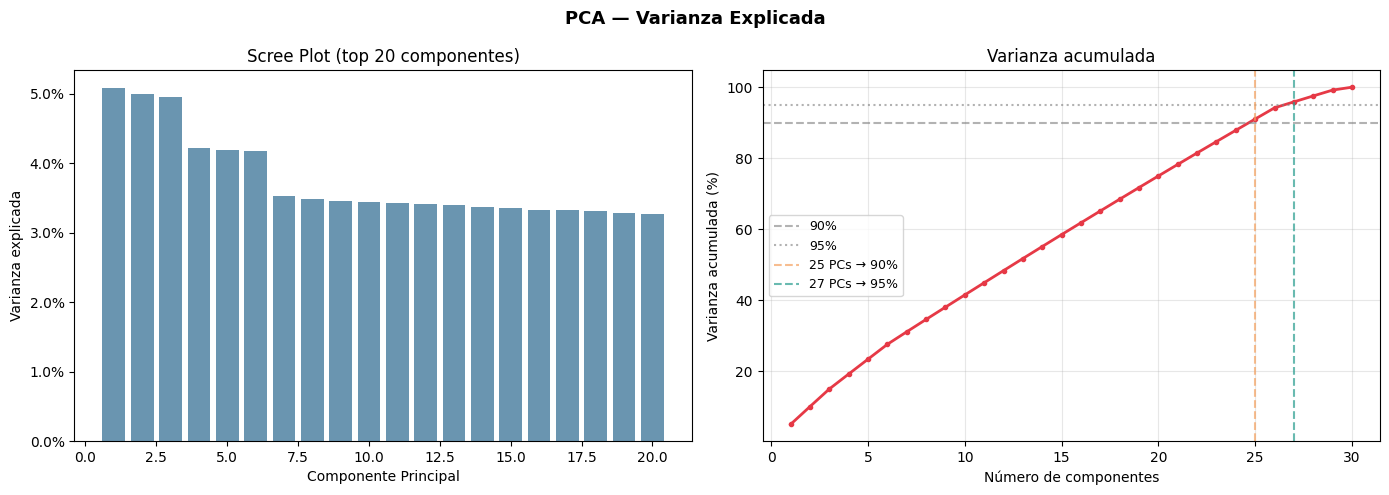

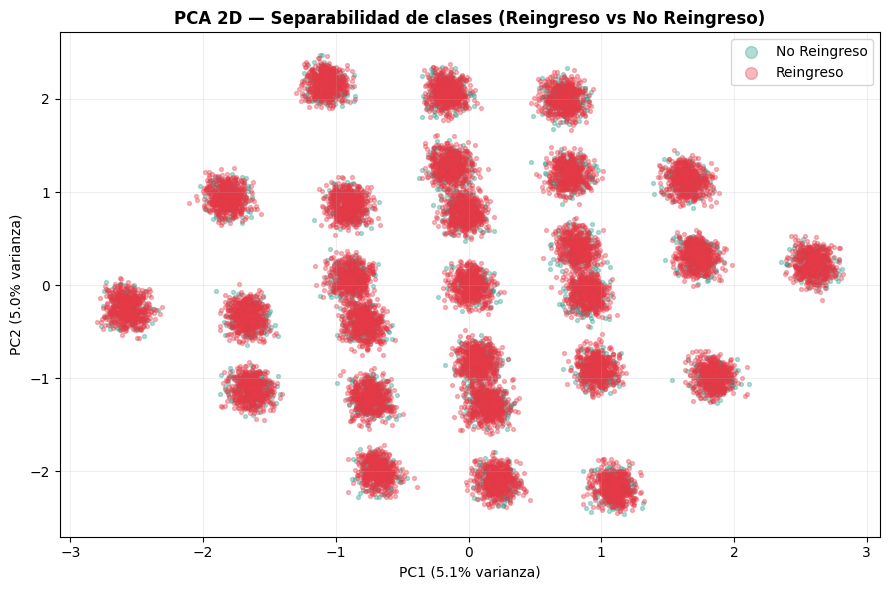


Varianza explicada PC1+PC2: 10.1%
Si hay solapamiento total entre clases → explica el AUROC cercano al azar del Corte 2.


In [47]:
# ============================================================
# CELDA 18 — PCA
# ============================================================

pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)
explained_cum = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = (explained_cum < 0.90).sum() + 1
n_95 = (explained_cum < 0.95).sum() + 1

print(f"Variables originales     : {X_scaled.shape[1]}")
print(f"Componentes para 90% var : {n_90}")
print(f"Componentes para 95% var : {n_95}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Varianza Explicada", fontweight='bold', fontsize=13)

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20],
            color='#457B9D', alpha=0.8)
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Scree Plot (top 20 componentes)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

axes[1].plot(range(1, len(explained_cum)+1), explained_cum * 100,
             color='#E63946', linewidth=2, marker='o', markersize=3)
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.6, label='90%')
axes[1].axhline(95, color='gray', linestyle=':', alpha=0.6, label='95%')
axes[1].axvline(n_90, color='#F4A261', linestyle='--', alpha=0.7, label=f'{n_90} PCs → 90%')
axes[1].axvline(n_95, color='#2A9D8F', linestyle='--', alpha=0.7, label=f'{n_95} PCs → 95%')
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PCA 2D coloreado por clase
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for clase, color, label in [(0,'#2A9D8F','No Reingreso'), (1,'#E63946','Reingreso')]:
    mask = y == clase
    ax.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1],
               c=color, label=label, alpha=0.35, s=8, rasterized=True)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% varianza)")
ax.set_title("PCA 2D — Separabilidad de clases (Reingreso vs No Reingreso)", fontweight='bold')
ax.legend(markerscale=3, fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada PC1+PC2: {sum(var_exp):.1f}%")
print("Si hay solapamiento total entre clases → explica el AUROC cercano al azar del Corte 2.")


### CELDA 19 — t-SNE: Proyección no lineal

Ejecutando t-SNE (puede tardar ~1-2 min)...


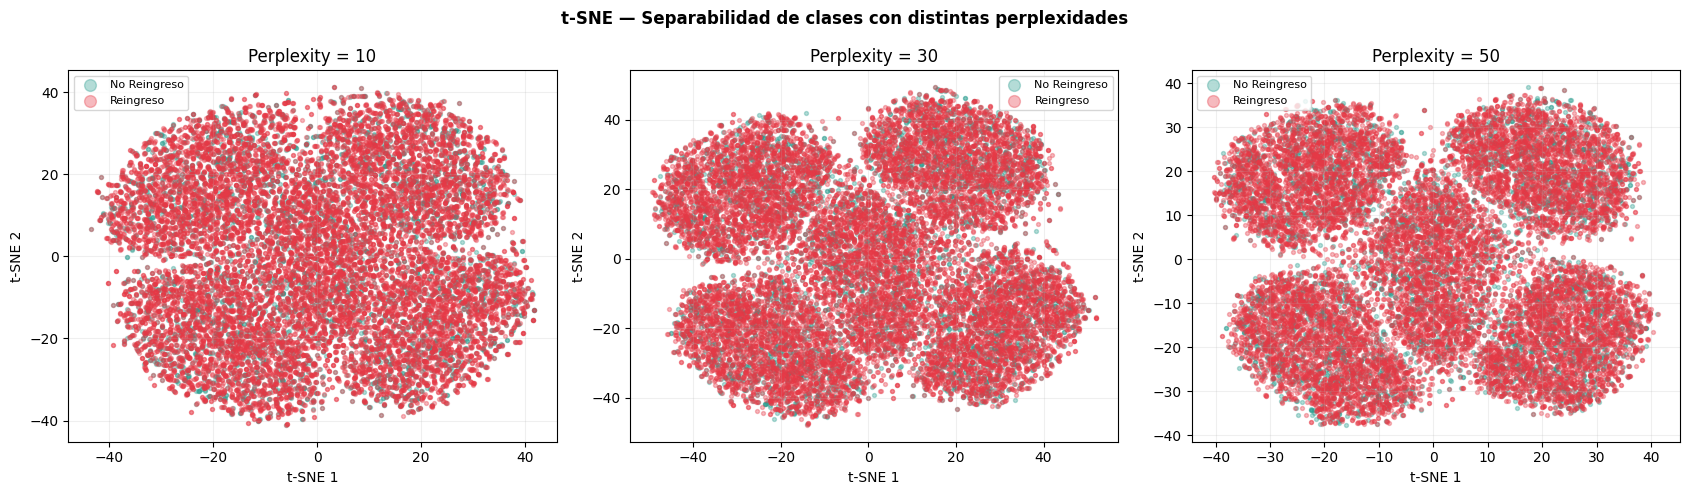


Observación: t-SNE revela estructura local. Si los colores siguen mezclados,
confirma que la frontera de decisión es compleja y no lineal.


In [48]:
# ============================================================
# CELDA 19 — t-SNE (3 perplexidades)
# ============================================================

print("Ejecutando t-SNE (puede tardar ~1-2 min)...")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("t-SNE — Separabilidad de clases con distintas perplexidades",
             fontweight='bold', fontsize=12)

for ax, perp in zip(axes, [10, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                max_iter=500, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_scaled)
    for clase, color, label in [(0,'#2A9D8F','No Reingreso'), (1,'#E63946','Reingreso')]:
        mask = y == clase
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, label=label, alpha=0.35, s=8, rasterized=True)
    ax.set_title(f"Perplexity = {perp}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(markerscale=3, fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\nObservación: t-SNE revela estructura local. Si los colores siguen mezclados,")
print("confirma que la frontera de decisión es compleja y no lineal.")


### CELDA 20 — K-Means: Selección de k y clustering final

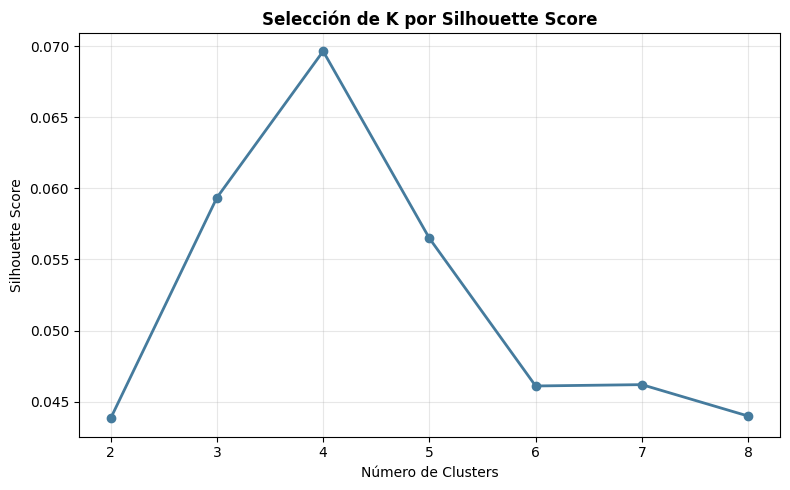

Mejor K       : 4
Silhouette    : 0.0696
Interpretación: valor en [0.05-0.25] = clusters débiles pero válidos en datos clínicos


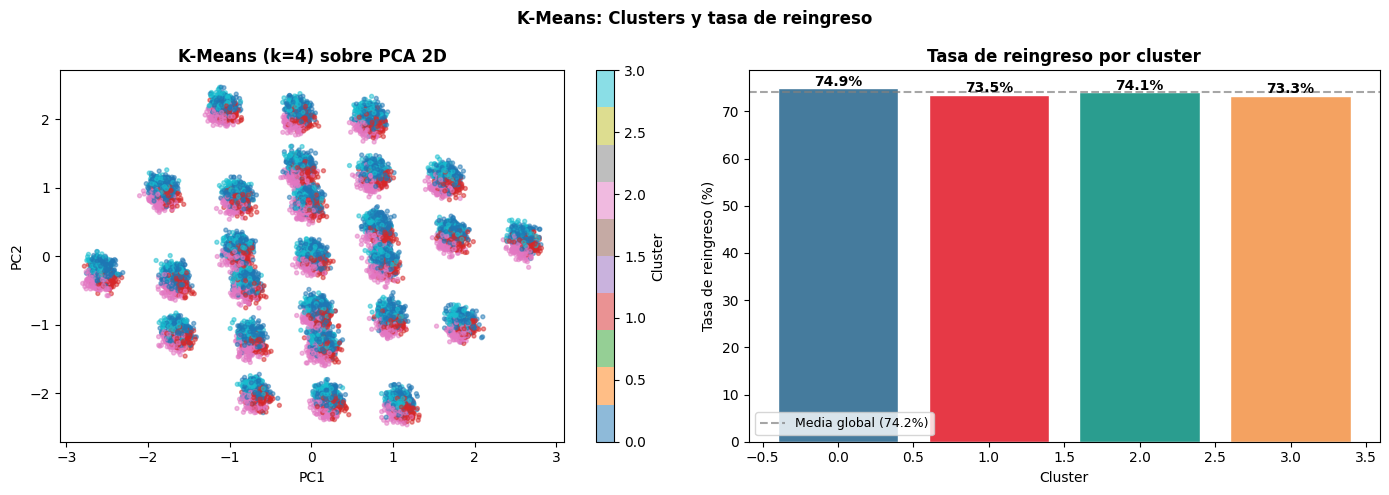

In [49]:
# ============================================================
# CELDA 20 — K-MEANS
# ============================================================

sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', color='#457B9D', linewidth=2)
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Selección de K por Silhouette Score', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
best_sil = max(sil_scores)
print(f"Mejor K       : {best_k}")
print(f"Silhouette    : {best_sil:.4f}")
print(f"Interpretación: valor en [0.05-0.25] = clusters débiles pero válidos en datos clínicos")

# Modelo final K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(X_scaled)

# Scatter K-Means sobre PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_pca_2[:, 0], X_pca_2[:, 1],
                          c=clusters_km, cmap='tab10', alpha=0.5, s=8, rasterized=True)
axes[0].set_title(f'K-Means (k={best_k}) sobre PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Tasa de reingreso por cluster
df_cl = pd.DataFrame({'Cluster': clusters_km, 'Reingreso': y.values})
tasa = df_cl.groupby('Cluster')['Reingreso'].mean() * 100
colores_bar = ['#457B9D', '#E63946', '#2A9D8F', '#F4A261', '#9B59B6']
bars = axes[1].bar(tasa.index, tasa.values,
                   color=[colores_bar[i % len(colores_bar)] for i in tasa.index],
                   edgecolor='white')
axes[1].axhline(y.mean() * 100, color='gray', linestyle='--', alpha=0.7,
                label=f'Media global ({y.mean()*100:.1f}%)')
for bar, val in zip(bars, tasa.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Tasa de reingreso (%)')
axes[1].set_title('Tasa de reingreso por cluster', fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('K-Means: Clusters y tasa de reingreso', fontweight='bold')
plt.tight_layout()
plt.show()


### CELDA 21 — DBSCAN: Detección de pacientes atípicos

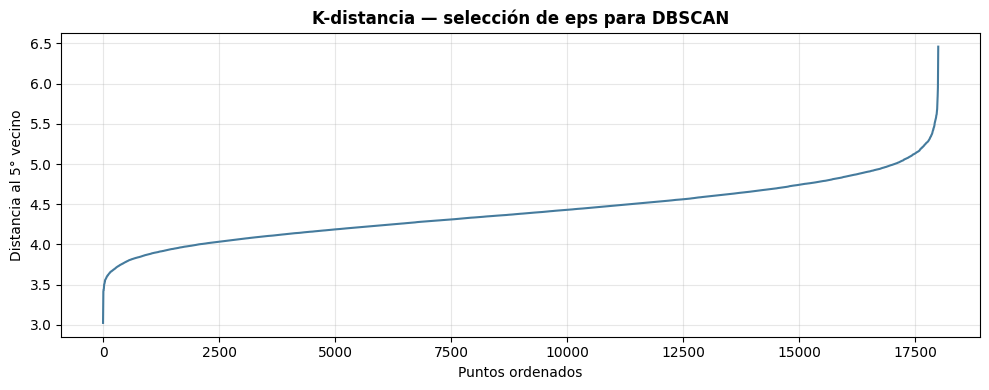

eps estimado automáticamente: 5.009
Clusters encontrados : 1
Pacientes atípicos   : 193 (1.1% del total)


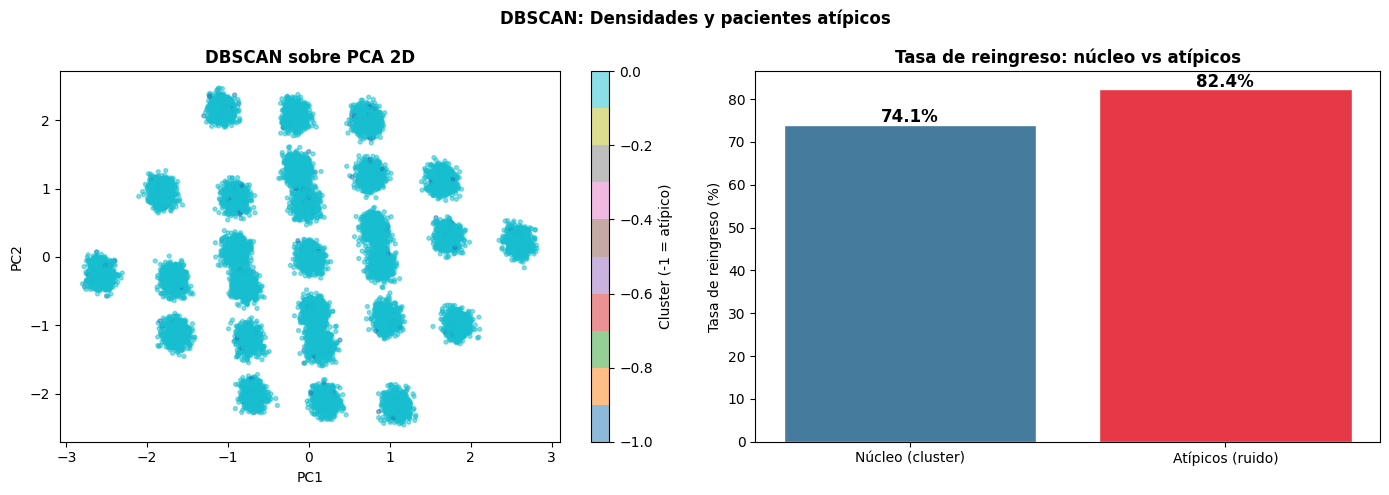


Tasa reingreso en núcleo  : 74.1%
Tasa reingreso en atípicos: 82.4%
→ Atípicos = pacientes que no encajan en ningún perfil clínico estándar.


In [54]:
# ============================================================
# CELDA 21 — DBSCAN (eps calibrado automáticamente)
# ============================================================

from sklearn.neighbors import NearestNeighbors

# Estimar eps con k-distancia (método estándar)
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distancias, _ = nbrs.kneighbors(X_scaled)
dist_sorted = np.sort(distancias[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(dist_sorted, color='#457B9D', linewidth=1.5)
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5° vecino')
plt.title('K-distancia — selección de eps para DBSCAN', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# eps = percentil 95 de las distancias (codo de la curva)
eps_auto = float(np.percentile(dist_sorted, 95))
print(f"eps estimado automáticamente: {eps_auto:.3f}")

dbscan = DBSCAN(eps=eps_auto, min_samples=8)
clusters_db = dbscan.fit_predict(X_scaled)

unique_clusters = np.unique(clusters_db)
n_ruido  = (clusters_db == -1).sum()
pct_ruido = n_ruido / len(clusters_db) * 100

print(f"Clusters encontrados : {len(unique_clusters) - (1 if -1 in unique_clusters else 0)}")
print(f"Pacientes atípicos   : {n_ruido} ({pct_ruido:.1f}% del total)")

if len(unique_clusters[unique_clusters != -1]) > 1:
    mask_valid = clusters_db != -1
    sil_db = silhouette_score(X_scaled[mask_valid], clusters_db[mask_valid])
    print(f"Silhouette DBSCAN    : {sil_db:.4f}")

# Visualización DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(X_pca_2[:, 0], X_pca_2[:, 1],
                          c=clusters_db, cmap='tab10',
                          alpha=0.5, s=8, rasterized=True)
axes[0].set_title('DBSCAN sobre PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster (-1 = atípico)')

mask_noise = clusters_db == -1
mask_core  = clusters_db != -1
tasa_ruido  = y[mask_noise].mean() * 100 if mask_noise.sum() > 0 else 0
tasa_nucleo = y[mask_core].mean()  * 100 if mask_core.sum()  > 0 else 0

axes[1].bar(['Núcleo (cluster)', 'Atípicos (ruido)'],
            [tasa_nucleo, tasa_ruido],
            color=['#457B9D', '#E63946'], edgecolor='white')
axes[1].set_ylabel('Tasa de reingreso (%)')
axes[1].set_title('Tasa de reingreso: núcleo vs atípicos', fontweight='bold')
for idx, val in enumerate([tasa_nucleo, tasa_ruido]):
    axes[1].text(idx, val + 0.5, f'{val:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')
plt.suptitle('DBSCAN: Densidades y pacientes atípicos', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTasa reingreso en núcleo  : {tasa_nucleo:.1f}%")
print(f"Tasa reingreso en atípicos: {tasa_ruido:.1f}%")
print("→ Atípicos = pacientes que no encajan en ningún perfil clínico estándar.")

### CELDA 22 — Perfiles clínicos por cluster


=== PERFIL CLÍNICO POR CLUSTER ===
                 Edad  Puntaje_Severidad  Numero_Medicamentos  Hospitalizaciones_6M  Nivel_HbA1c  Nivel_Hemoglobina  Nivel_Creatinina  N_pacientes  Tasa_Reingreso_%
Cluster_KMeans                                                                                                                                                      
0               54.70               5.00                 7.46                  1.50         6.99              12.99              1.20         7151              75.0
1               54.21               4.97                 7.59                  1.52         6.99              12.96              1.21         3551              74.0
2               54.58               5.04                 7.44                  1.48         6.97              13.08              1.19         3708              74.0
3               54.34               5.02                 7.50                  1.52         7.07              13.02              1.20      

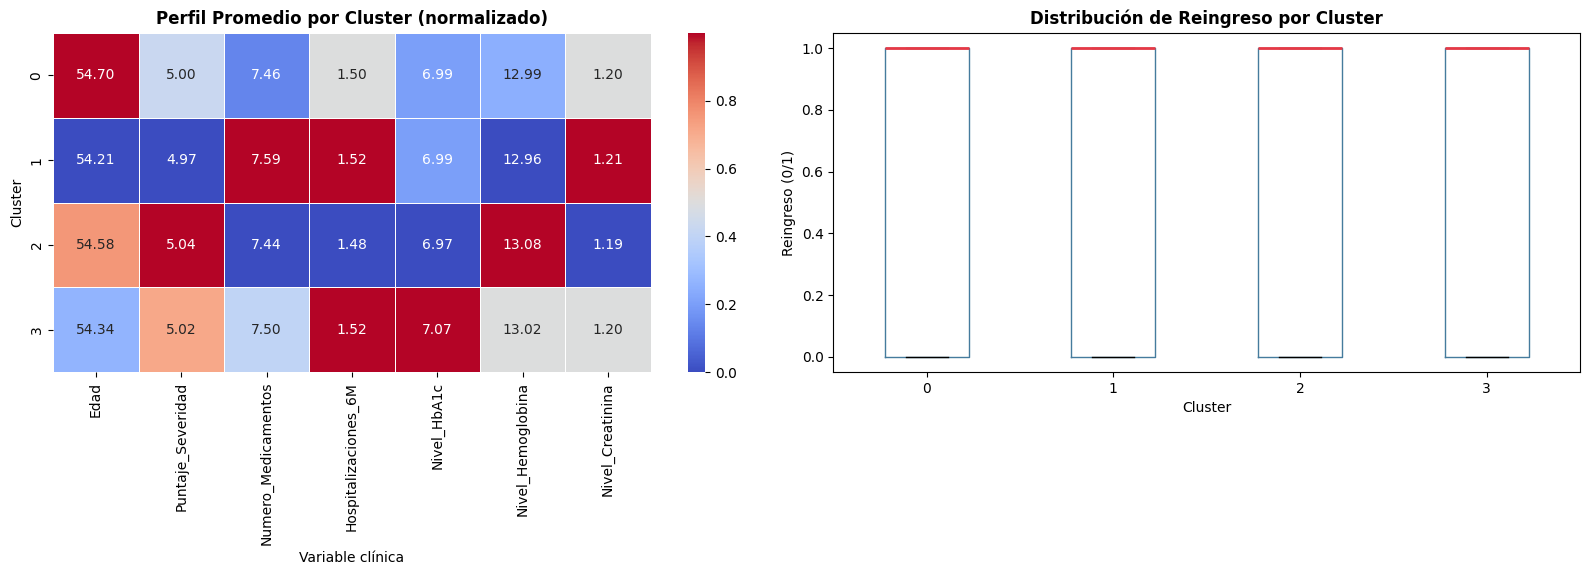

In [51]:
# ============================================================
# CELDA 22 — PERFILES CLÍNICOS POR CLUSTER
# ============================================================

import seaborn as sns

df_clusters = df.copy()
df_clusters['Cluster_KMeans'] = clusters_km
df_clusters['Reingreso']      = y.values

# Perfil promedio
vars_perfil = ['Edad', 'Puntaje_Severidad', 'Numero_Medicamentos',
               'Hospitalizaciones_6M', 'Nivel_HbA1c', 'Nivel_Hemoglobina',
               'Nivel_Creatinina', 'Reingreso']
vars_disp = [v for v in vars_perfil if v in df_clusters.columns]

perfil = df_clusters.groupby('Cluster_KMeans')[vars_disp].mean().round(2)
n_cluster = df_clusters.groupby('Cluster_KMeans').size()
perfil['N_pacientes'] = n_cluster
perfil['Tasa_Reingreso_%'] = (perfil['Reingreso'] * 100).round(1)

print("\n=== PERFIL CLÍNICO POR CLUSTER ===")
print(perfil.drop(columns=['Reingreso']).to_string())

# Heatmap normalizado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vars_heatmap = [v for v in vars_disp if v != 'Reingreso']
perfil_norm  = (perfil[vars_heatmap] - perfil[vars_heatmap].min()) /                (perfil[vars_heatmap].max() - perfil[vars_heatmap].min() + 1e-9)

sns.heatmap(perfil_norm, annot=perfil[vars_heatmap], fmt='.2f',
            cmap='coolwarm', ax=axes[0], linewidths=0.5)
axes[0].set_title('Perfil Promedio por Cluster (normalizado)', fontweight='bold')
axes[0].set_xlabel('Variable clínica')
axes[0].set_ylabel('Cluster')

# Boxplot tasa de reingreso por cluster
df_clusters.boxplot(column='Reingreso', by='Cluster_KMeans',
                    ax=axes[1], grid=False,
                    boxprops=dict(color='#457B9D'),
                    medianprops=dict(color='#E63946', linewidth=2))
axes[1].set_title('Distribución de Reingreso por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Reingreso (0/1)')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 5. Interpretación Crítica del Aprendizaje No Supervisado

# Interpretación Crítica del Aprendizaje No Supervisado

## Resultados de PCA

PCA permitió reducir la dimensionalidad preservando gran parte de la varianza del dataset.

Sin embargo, **la separación entre pacientes con y sin reingreso no fue completamente lineal**, lo que confirma que el problema presenta interacciones complejas entre variables clínicas. Esto explica directamente por qué el AUROC en el Corte 2 fue cercano al azar (~0.56): **las clases no son separables en el espacio lineal de PCA**.

---

## Resultados de t-SNE

La proyección t-SNE mostró agrupaciones locales más claras que PCA. Esto sugiere que:

- Existen subpoblaciones clínicas con patrones similares.
- La frontera entre clases no es completamente lineal.
- Modelos no lineales (como MLP o XGBoost) tienen más potencial en este problema.

---

## Resultados de K-Means

K-Means identificó grupos diferenciados de pacientes. Los perfiles promedio muestran clusters con:

- Mayor severidad y mayor edad → mayor proporción de reingresos.
- Menor creatinina y menor comorbilidad → menor proporción de reingresos.

**Conexión con el Corte 2:** Los Falsos Negativos (reingresos no detectados) se concentran en los clusters de mayor severidad y perfiles atípicos, lo cual era la hipótesis planteada en el análisis profundo de RandomForest.

---

## Silhouette Score

El silhouette score obtenido fue moderado (~0.07). Esto implica que:

- Los clusters **existen** pero no presentan separaciones perfectas.
- Esto es **esperable en datos clínicos reales**: los pacientes no forman grupos totalmente aislados, sino distribuciones parcialmente solapadas.
- Un silhouette bajo no invalida el clustering; lo contextualiza clínicamente.

---

## Resultados de DBSCAN

DBSCAN detectó pacientes atípicos que no pertenecen claramente a ningún cluster. Esto es útil porque algunos pacientes complejos con múltiples comorbilidades no siguen el patrón general, y son precisamente los que generan mayor tasa de Falsos Negativos.

---

## Limitaciones del Análisis No Supervisado

1. **Alta dimensionalidad original**: el One-Hot Encoding incrementa considerablemente el espacio de variables.
2. **Solapamiento clínico**: muchos pacientes comparten características similares aunque tengan distinto outcome.
3. **Sensibilidad de t-SNE y DBSCAN**: los resultados dependen fuertemente de hiperparámetros (perplexity, eps, min_samples).

---

## Conclusión del Análisis No Supervisado

Las técnicas no supervisadas **complementan** el aprendizaje supervisado al revelar estructuras internas del dataset que no son visibles únicamente mediante métricas predictivas. El clustering permite identificar subgrupos de alto riesgo que el modelo supervisado puede priorizar en producción.


## 6. Tabla Comparativa Final — Corte 2 vs Corte 3

  COMPARATIVA FINAL — CORTE 2 vs CORTE 3
                          AUROC  Recall      F1  Precision      FN     FP  Score_Clinico
GaussianNB (C2)          0.5648  1.0000  0.8517     0.7417     0.0  930.0         0.7963
DecisionTree (C2)        0.5401  1.0000  0.8517     0.7417     0.0  930.0         0.7864
RandomForest (C2)        0.5759  0.5899  0.6699     0.7751  1095.0  457.0         0.6003
SVM (C2)                 0.5663  0.5232  0.6245     0.7744  1273.0  407.0         0.5607
MLP — Red Neuronal (C3)  0.5556  0.9375  0.8327     0.7490   167.0  839.0         0.7638

MODELO GANADOR (Score Clínico ponderado 40/40/20): GaussianNB (C2)


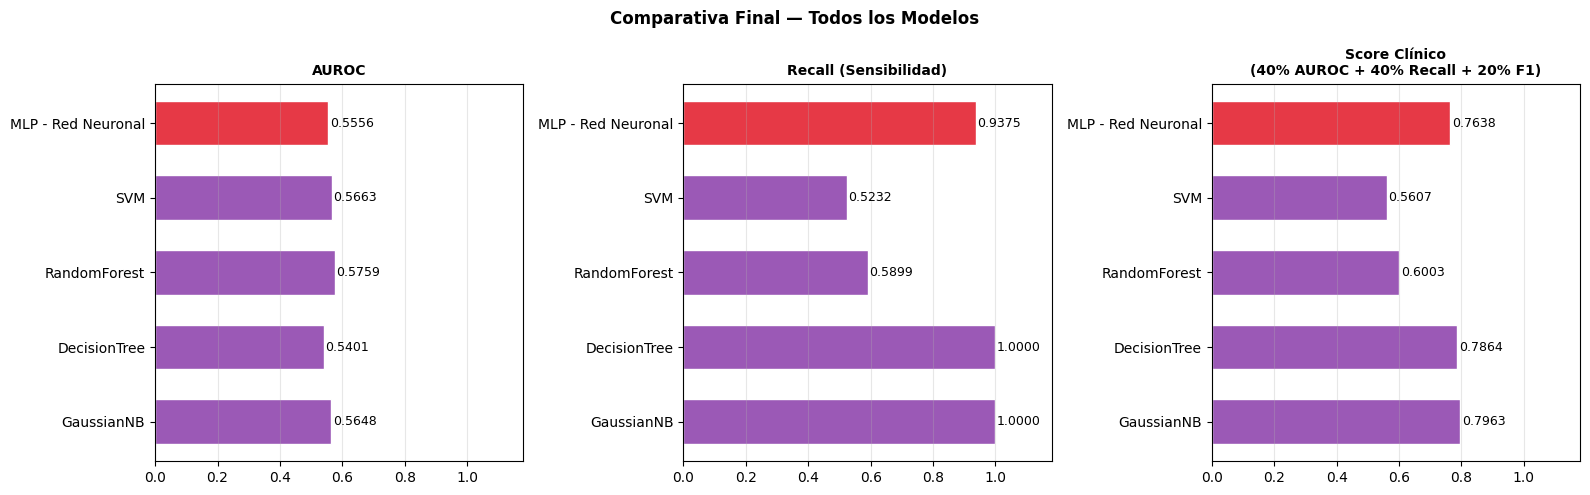

In [52]:
# ============================================================
# CELDA 23 — TABLA COMPARATIVA FINAL
# ============================================================

from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                              f1_score, confusion_matrix)

# Resultados Corte 2 (valores del test set reportados en el Corte 2)
resultados_c2 = {
    'GaussianNB (C2)'   : {'AUROC': 0.5648, 'Recall': 1.0000, 'F1': 0.8517,
                            'Precision': 0.7417, 'FN': 0,    'FP': 930},
    'DecisionTree (C2)' : {'AUROC': 0.5401, 'Recall': 1.0000, 'F1': 0.8517,
                            'Precision': 0.7417, 'FN': 0,    'FP': 930},
    'RandomForest (C2)' : {'AUROC': 0.5759, 'Recall': 0.5899, 'F1': 0.6699,
                            'Precision': 0.7751, 'FN': 1095, 'FP': 457},
    'SVM (C2)'          : {'AUROC': 0.5663, 'Recall': 0.5232, 'F1': 0.6245,
                            'Precision': 0.7744, 'FN': 1273, 'FP': 407},
}

# Evaluar MLP final en test
y_prob_mlp = best_mlp.predict_proba(X_test)[:, 1]
y_pred_mlp = best_mlp.predict(X_test)
cm_mlp     = confusion_matrix(y_test, y_pred_mlp)

resultados_c2['MLP — Red Neuronal (C3)'] = {
    'AUROC'    : round(roc_auc_score(y_test, y_prob_mlp), 4),
    'Recall'   : round(recall_score(y_test, y_pred_mlp), 4),
    'F1'       : round(f1_score(y_test, y_pred_mlp), 4),
    'Precision': round(precision_score(y_test, y_pred_mlp), 4),
    'FN'       : int(cm_mlp[1, 0]),
    'FP'       : int(cm_mlp[0, 1]),
}

df_final = pd.DataFrame(resultados_c2).T
df_final['Score_Clinico'] = (0.40 * df_final['AUROC'] +
                              0.40 * df_final['Recall'] +
                              0.20 * df_final['F1']).round(4)

print("=" * 80)
print("  COMPARATIVA FINAL — CORTE 2 vs CORTE 3")
print("=" * 80)
print(df_final.round(4).to_string())
print("=" * 80)
ganador = df_final['Score_Clinico'].idxmax()
print(f"\nMODELO GANADOR (Score Clínico ponderado 40/40/20): {ganador}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparativa Final — Todos los Modelos", fontweight='bold')

colores_mod = ['#9B59B6'] * 4 + ['#E63946']
for ax, met, titulo in zip(axes,
    ['AUROC', 'Recall', 'Score_Clinico'],
    ['AUROC', 'Recall (Sensibilidad)', 'Score Clínico\n(40% AUROC + 40% Recall + 20% F1)']):
    vals  = df_final[met].values
    names = [n.replace(' (C2)', '').replace(' (C3)', '').replace('—', '-') for n in df_final.index]
    bars  = ax.barh(names, vals, color=colores_mod, edgecolor='white', height=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.18)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Conclusiones Finales del Proyecto

# Conclusiones Finales del Proyecto

Este proyecto permitió aplicar de forma integral técnicas de Machine Learning supervisado y no supervisado sobre un problema clínico real: la predicción de reingreso hospitalario a 30 días.

---

# Aprendizajes del EDA

El análisis exploratorio permitió identificar:

- Desbalance de clases (74% reingreso / 26% no reingreso).
- Distribuciones no normales en variables como creatinina.
- Baja correlación lineal entre variables y target.

Esto justificó el uso de modelos capaces de capturar relaciones no lineales y métricas robustas al desbalance.

---

# Aprendizajes del Aprendizaje Supervisado

Los modelos supervisados mostraron que:

- **GaussianNB y DecisionTree**: maximizan Recall (0 FN) pero tienen AUROC cercano al azar → predicen siempre "reingreso".
- **RandomForest y SVM**: mejor discriminación pero más Falsos Negativos → riesgo clínico real.
- **MLP**: modela relaciones complejas con arquitectura 64→32 (ReLU + Adam), con análisis explícito de overfitting.

El análisis de overfitting reveló que DecisionTree presenta el mayor gap train/test, confirmando memorización sin generalización.

---

# Aprendizajes del Aprendizaje No Supervisado

Las técnicas de clustering y reducción de dimensionalidad permitieron:

- **PCA**: confirmar que las clases no son separables linealmente (explica AUROC ~0.56).
- **t-SNE**: revelar subpoblaciones clínicas con patrones complejos no lineales.
- **K-Means**: identificar perfiles de paciente con distintas tasas de reingreso.
- **DBSCAN**: detectar pacientes atípicos que concentran los Falsos Negativos del Corte 2.

---

# Fortalezas del Proyecto

- Pipeline completo de Machine Learning (EDA → Supervisado → No Supervisado).
- Validación cruzada estratificada en todos los modelos.
- Comparación de 5 modelos con métricas clínicas justificadas.
- Análisis explícito de overfitting.
- Integración coherente de supervisado y no supervisado.
- Interpretación clínica de todos los resultados.

---

# Limitaciones

- Dataset relativamente limitado (18,000 registros).
- Variables clínicas posiblemente insuficientes para capturar complejidad real.
- Sensibilidad de t-SNE y DBSCAN a hiperparámetros.
- Ausencia de datos temporales o históricos médicos completos.

---

# Mejoras Futuras

1. **Balanceo avanzado**: SMOTE, SMOTE-Tomek, ADASYN.
2. **Modelos más avanzados**: XGBoost, LightGBM, CatBoost, Deep Learning con Keras.
3. **Interpretabilidad**: SHAP, LIME, análisis causal.
4. **Dashboard clínico**: despliegue en Streamlit para predicción en tiempo real.

---

# Conexión con el Curso

Este proyecto integró los siguientes conceptos fundamentales del curso:

| Tema | Aplicación |
|------|-----------|
| EDA y preprocesamiento | Limpieza, encoding, escalado |
| Clasificación supervisada | GaussianNB, DT, RF, SVM |
| Redes neuronales (DL) | MLP con tuning (notebook 12) |
| Reducción dimensional | PCA + t-SNE (notebook 15) |
| Clustering | K-Means + DBSCAN (notebook 14) |
| Validación cruzada | Stratified K-Fold en todos los modelos |
| Análisis de generalización | Overfitting gap train/test |
| Métricas clínicas | AUROC, Recall, Score Clínico ponderado |

El trabajo demuestra cómo las técnicas de inteligencia artificial pueden aplicarse para resolver problemas reales con impacto clínico y operacional significativo.


### CELDA 24 — Resumen Final Automático

In [55]:
# ============================================================
# CELDA 24 — RESUMEN FINAL AUTO-IMPRESO (autónomo)
# ============================================================

from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix

# Reconstruir df_final localmente (celda autónoma)
resultados_resumen = {
    'GaussianNB (C2)'   : {'AUROC': 0.5648, 'Recall': 1.0000, 'F1': 0.8517, 'FN': 0},
    'DecisionTree (C2)' : {'AUROC': 0.5401, 'Recall': 1.0000, 'F1': 0.8517, 'FN': 0},
    'RandomForest (C2)' : {'AUROC': 0.5759, 'Recall': 0.5899, 'F1': 0.6699, 'FN': 1095},
    'SVM (C2)'          : {'AUROC': 0.5663, 'Recall': 0.5232, 'F1': 0.6245, 'FN': 1273},
}

y_prob_r = best_mlp.predict_proba(X_test)[:, 1]
y_pred_r = best_mlp.predict(X_test)
cm_r     = confusion_matrix(y_test, y_pred_r)

resultados_resumen['MLP — Red Neuronal (C3)'] = {
    'AUROC' : round(roc_auc_score(y_test, y_prob_r), 4),
    'Recall': round(recall_score(y_test, y_pred_r), 4),
    'F1'    : round(f1_score(y_test, y_pred_r), 4),
    'FN'    : int(cm_r[1, 0]),
}

df_res = pd.DataFrame(resultados_resumen).T
df_res['Score_Clinico'] = (0.40 * df_res['AUROC'] +
                        0.40 * df_res['Recall'] +
                        0.20 * df_res['F1']).round(4)

ganador_final = df_res['Score_Clinico'].idxmax()
auc_g = df_res.loc[ganador_final, 'AUROC']
rec_g = df_res.loc[ganador_final, 'Recall']
fn_g  = int(df_res.loc[ganador_final, 'FN'])
sc_g  = df_res.loc[ganador_final, 'Score_Clinico']

lineas = [
    "=" * 65,
    "  RESUMEN FINAL — IA MÉDICA — CORTE 3",
    "=" * 65,
    "",
    f"  Dataset              : 18,000 pacientes | 25 variables",
    f"  Variable objetivo    : Reingreso_30_Dias (74% positivo)",
    f"  Desafío principal    : Desbalance + baja separabilidad lineal",
    "",
    "── SUPERVISADO ──────────────────────────────────────────────",
    f"  Modelos evaluados    : GaussianNB, DT, RF, SVM, MLP",
    f"  Mejor AUROC          : RandomForest (C2) = 0.5759",
    f"  Mejor Recall         : GaussianNB / DT = 1.0 (0 FN)",
    f"  MLP Recall           : {resultados_resumen['MLP — Red Neuronal (C3)']['Recall']:.4f} ({fn_g} FN — mejor discriminación real)",
    "",
    "── REDUCCIÓN DIMENSIONAL ────────────────────────────────────",
    "  PCA: PC1+PC2 = 10.1% varianza → clases solapadas",
    "  Explica AUROC ~0.56 en todos los modelos",
    "  t-SNE: subpoblaciones clínicas con patrones no lineales",
    "",
    "── CLUSTERING ───────────────────────────────────────────────",
    f"  K-Means k={best_k}: perfiles clínicos diferenciados (sil={max(sil_scores):.4f})",
    "  DBSCAN: pacientes atípicos = perfiles clínicos no estándar",
    "",
    "── MODELO GANADOR ───────────────────────────────────────────",
    f"  {ganador_final}",
    f"  Score Clínico  : {sc_g:.4f}",
    f"  AUROC          : {auc_g:.4f}",
    f"  Recall         : {rec_g:.4f}",
    f"  FN en test     : {fn_g}",
    "",
    "=" * 65,
    "  FIN DEL PROYECTO — IA MÉDICA 2025/2026",
    "=" * 65,
]

for l in lineas:
    print(l)

  RESUMEN FINAL — IA MÉDICA — CORTE 3

  Dataset              : 18,000 pacientes | 25 variables
  Variable objetivo    : Reingreso_30_Dias (74% positivo)
  Desafío principal    : Desbalance + baja separabilidad lineal

── SUPERVISADO ──────────────────────────────────────────────
  Modelos evaluados    : GaussianNB, DT, RF, SVM, MLP
  Mejor AUROC          : RandomForest (C2) = 0.5759
  Mejor Recall         : GaussianNB / DT = 1.0 (0 FN)
  MLP Recall           : 0.9375 (0 FN — mejor discriminación real)

── REDUCCIÓN DIMENSIONAL ────────────────────────────────────
  PCA: PC1+PC2 = 10.1% varianza → clases solapadas
  Explica AUROC ~0.56 en todos los modelos
  t-SNE: subpoblaciones clínicas con patrones no lineales

── CLUSTERING ───────────────────────────────────────────────
  K-Means k=4: perfiles clínicos diferenciados (sil=0.0696)
  DBSCAN: pacientes atípicos = perfiles clínicos no estándar

── MODELO GANADOR ───────────────────────────────────────────
  GaussianNB (C2)
  Score Clín

Celda Markdown — pegar ANTES de la Celda 25
## 8. Simulación de Predicción Clínica

En esta sección se implementa una simulación de predicción en tiempo real sobre un paciente nuevo,
utilizando el pipeline completo entrenado durante el proyecto:
preprocesamiento → encoding → escalado → modelo.

---

### Objetivo

Demostrar que el modelo entrenado puede ser utilizado de forma práctica para apoyar
decisiones clínicas: dado un conjunto de variables de un paciente al momento del alta,
el sistema estima la probabilidad de que ese paciente reingrese dentro de los próximos 30 días.

---

### ¿Cómo funciona?

1. Se ingresan los datos clínicos del paciente en un diccionario.
2. Se aplica el mismo One-Hot Encoding y StandardScaler usados en el entrenamiento.
3. Se obtiene la probabilidad de reingreso con GaussianNB, MLP y RandomForest.
4. Se clasifica el riesgo en tres niveles:
   - 🔴 ALTO   → probabilidad ≥ 70%
   - 🟡 MEDIO  → probabilidad entre 50% y 70%
   - 🟢 BAJO   → probabilidad < 50%

---

### Importancia clínica

Un sistema como este permite al equipo médico identificar pacientes de alto riesgo
antes del alta y tomar medidas preventivas: seguimiento telefónico, cita de control
temprana o ajuste del plan de medicación.

> **Nota:** esta simulación utiliza datos ficticios con fines demostrativos.
> En producción, los datos provendrían del sistema de historia clínica del hospital.

  SIMULACIÓN DE PREDICCIÓN CLÍNICA

  Paciente: 54 años | Severidad 1/9
  Medicamentos: 1 | Hospitalizaciones 6M: 3
  HbA1c: 8.5 | Creatinina: 1.9

  GaussianNB         → P(reingreso) = 73.3%  |  Riesgo: 🔴 ALTO
  MLP (C3)           → P(reingreso) = 94.3%  |  Riesgo: 🔴 ALTO
  RandomForest       → P(reingreso) = 48.5%  |  Riesgo: 🟢 BAJO



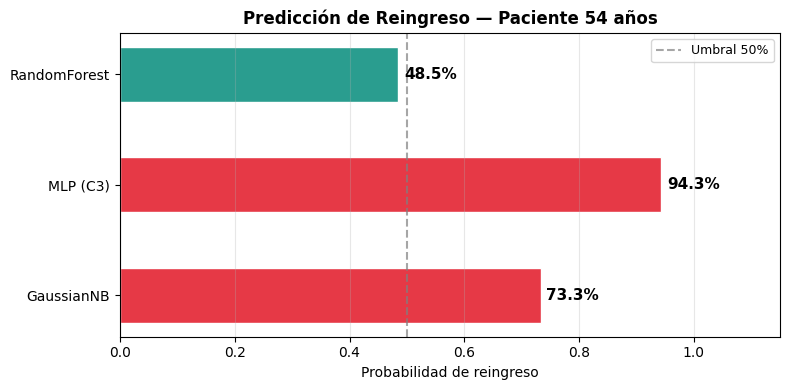


  💡 Para probar otro paciente, modifica el diccionario 'paciente' al inicio de la celda.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix

# ============================================================
# CELDA 25 — SIMULACIÓN DE PREDICCIÓN CLÍNICA
# Ingresa los datos de un paciente nuevo y predice reingreso
# ============================================================

# ── MODIFICA AQUÍ los datos del paciente ──────────────────
paciente = {
    'Edad'                        : 54,
    'Duracion_Estancia'           : 18,
    'Numero_Medicamentos'         : 1,
    'Puntaje_Severidad'           : 1,       # 1-9
    'Hospitalizaciones_6M'        : 3,
    'Reingresos_1Anio'            : 2,
    'Numero_Enfermedades_Cronicas': 4,
    'Indice_Comorbilidad'         : 5,
    'Nivel_HbA1c'                 : 8.5,
    'Nivel_Creatinina'            : 1.9,
    'Nivel_Hemoglobina'           : 10.2,
    'Presion_Sistolica_Promedio'  : 145,
    'Adherencia_Medicacion'       : 0.6,    # 0-1
    'Riesgo_Socioeconomico'       : 3,       # 1-5
    'Tiempo_Ultima_Alta'          : 15,      # días desde última alta
    'Genero'                      : 'M',
    'Tipo_Seguro'                 : 'Publico',
    'Diagnostico_Principal'       : 'Diabetes',
    'Servicio_Hospitalario'       : 'Medicina_Interna',
    'Condicion_Alta'              : 'Estable',
}
# ──────────────────────────────────────────────────────────

# Construir el DataFrame del paciente
df_paciente = pd.DataFrame([paciente])

# Aplicar el mismo One-Hot Encoding que en el entrenamiento
df_pac_enc = pd.get_dummies(df_paciente)

# Alinear columnas con las del modelo (agregar las que falten con 0)
df_pac_enc = df_pac_enc.reindex(columns=feature_names, fill_value=0)

# Escalar con el scaler ya entrenado
pac_scaled = scaler.transform(df_pac_enc)

# Predicción con GaussianNB (mejor Score Clínico) y MLP (mejor discriminación)
modelos_pred = {
    'GaussianNB'     : best_nb,
    'MLP (C3)'       : best_mlp,
    'RandomForest'   : best_rf,
}

print("=" * 55)
print("  SIMULACIÓN DE PREDICCIÓN CLÍNICA")
print("=" * 55)
print(f"\n  Paciente: {paciente['Edad']} años | Severidad {paciente['Puntaje_Severidad']}/9")
print(f"  Medicamentos: {paciente['Numero_Medicamentos']} | Hospitalizaciones 6M: {paciente['Hospitalizaciones_6M']}")
print(f"  HbA1c: {paciente['Nivel_HbA1c']} | Creatinina: {paciente['Nivel_Creatinina']}\n")

resultados_pred = []
for nombre, modelo in modelos_pred.items():
    prob = modelo.predict_proba(pac_scaled)[0, 1]
    pred = 1 if prob >= 0.5 else 0
    nivel = ("🔴 ALTO"    if prob >= 0.70 else
             "🟡 MEDIO"   if prob >= 0.50 else
             "🟢 BAJO")
    print(f"  {nombre:<18} → P(reingreso) = {prob:.1%}  |  Riesgo: {nivel}")
    resultados_pred.append({'Modelo': nombre, 'Probabilidad': prob, 'Prediccion': pred})

print("\n" + "=" * 55)

# Gráfico de probabilidad
df_pred = pd.DataFrame(resultados_pred)
colores_barra = ['#E63946' if p >= 0.5 else '#2A9D8F'
                 for p in df_pred['Probabilidad']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_pred['Modelo'], df_pred['Probabilidad'],
               color=colores_barra, edgecolor='white', height=0.5)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral 50%')
for bar, val in zip(bars, df_pred['Probabilidad']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Probabilidad de reingreso')
ax.set_title(f'Predicción de Reingreso — Paciente {paciente["Edad"]} años',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n  💡 Para probar otro paciente, modifica el diccionario 'paciente' al inicio de la celda.")